In [1]:
#%matplotlib widget
#%config InlineBackend.figure_format='retina'

#from pathfinder import init_zhk

#init_zhk(r"C:\Users\AsherJennings\anaconda3\envs\qcodes\Lib\site-packages\zeroheliumkit")  # enter your zhk directory here

In [34]:
import yaml
import numpy as np
import matplotlib.pyplot as plt
from zeroheliumkit import GeomCollection, SuperStructure, Anchor
from zeroheliumkit import Circle
from zeroheliumkit.fem import *
from zeroheliumkit.fem.fieldreader import read_ff_output
from zeroheliumkit.src.settings import *
from zeroheliumkit.helpers.constants import *
from shapely.affinity import translate
from shapely import simplify
import os

print("ok")

ok


In [35]:
from zeroheliumkit.src.importing import Reader_DXF

sim2/sample_resevoir_10x10_no_bond_lines.dxf // Layers : dict_keys(['EBEAMLITHO_SMALLPADS', '0', 'EBEAMLITHO_GUARDS'])
0.06666666666666668
0.03333333333333334
Layers:['EBEAMLITHO_SMALLPADS', '0', 'EBEAMLITHO_GUARDS', 'Pillar0', 'Pillar1', 'Pillar2']


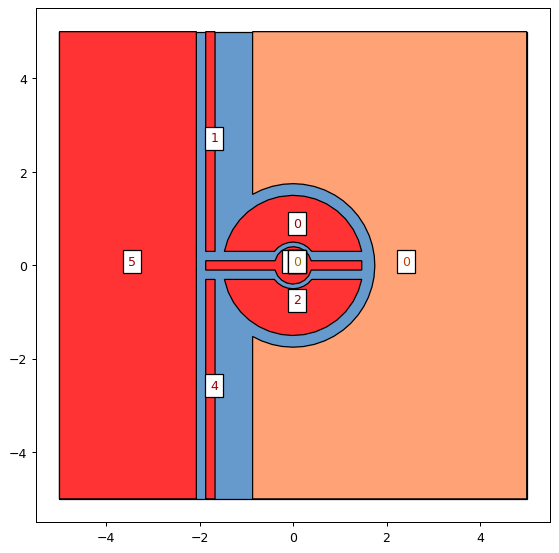

In [15]:
dirname = 'sim2/'
test = GeomCollection(Reader_DXF(dirname+"sample_resevoir_10x10_no_bond_lines.dxf").geometries)       # a new way to import files
cm = test.EBEAMLITHO_SMALLPADS.centroid
# test.moveby((-cm.x, -cm.y))
pillar = Circle(0.1, num_edges=10)
test.add_layer("Pillar0", pillar)


plot_config = {"anchors": CYAN,
               "0": BLUE,
               "EBEAMLITHO_GUARDS": ORANGE,
               "EBEAMLITHO_SMALLPADS": RED,
               "Pillar0": GREEN}

N = 3 #N >= 1, with N=1 mean the pillar is composed of 1 cylinder
for i in range(N-1):
    #add circles 
    # diameter 100 nm 
    test.add_layer("Pillar%i"%(i+1), Circle(0.1-(i+1)*0.1/N, num_edges=10))
    print(0.1-(i+1)*0.1/N)
    plot_config["Pillar%i"%(i+1)] = YELLOW
test.EBEAMLITHO_GUARDS = simplify(test.EBEAMLITHO_GUARDS, 0.01)         # this helps to reduce the number of points in a circular regions, otherwise #D geometry build and mesh generation is very slow
test.EBEAMLITHO_SMALLPADS = simplify(test.EBEAMLITHO_SMALLPADS, 0.01)   # same here
plot = test.quickplot(plot_config, show_idx=True)
print('Layers:' + str(test.layers))



In [40]:
d_bottom = 0.05
d_box = 5
d_sio2 = 0.120 # insulating layer (the insulating layer is between 120 and 380 nm)
d_guard = 0.38
if N==1:
    # if no circles are added to the layer
    d_pillar = 0.35
else:
    d_pillar = 0.3


d_He = d_sio2+d_guard+0.04

""" 
extrude_config: 
key - gmsh layer name
item - gmshLayer_info dict: 
       (geometry layer, z0, thickness, Physical Vol Name, CUT gmsh layer=None, forConstruction=False)
"""
extrude_config = {
    'wafer': gmshLayer_info('0', -d_box/2, d_box/2, 'DIELECTRIC'), # silicon bottom, why don't you create the wafer between -d_box/2 and 0 ?
    'bottom': gmshLayer_info('EBEAMLITHO_SMALLPADS', 0, d_bottom, 'METAL'),
    'sio2':  gmshLayer_info('EBEAMLITHO_GUARDS', 0, d_sio2, 'DIELECTRIC', ('bottom',)),  # thickness of the insulating layer, creates a vacuum in position of the electrodes   # this is where the main problem was
    'guard': gmshLayer_info('EBEAMLITHO_GUARDS', d_sio2,  d_guard, 'METAL'), #thickness of the guard
    'pillar_base': gmshLayer_info('Pillar0', d_bottom,  d_pillar, 'METAL')  ,
}


""" 
electrodes_config: 
key - physicalSurface name
item - physSurface_info dict:
       (geometry layer, electrode idx in geometry layer, gmsh layer)
"""
electrodes_config = {
    'half_donut_top':       physSurface_info('EBEAMLITHO_SMALLPADS', [0], 'bottom'),
    'half_donut_bottom':       physSurface_info('EBEAMLITHO_SMALLPADS', [2], 'bottom'),
    'gate_top':       physSurface_info('EBEAMLITHO_SMALLPADS', [1], 'bottom'),
    'gate_bottom':       physSurface_info('EBEAMLITHO_SMALLPADS', [4], 'bottom'),
    'reservoir':       physSurface_info('EBEAMLITHO_SMALLPADS', [5], 'bottom'),
    'center':       physSurface_info('EBEAMLITHO_SMALLPADS', [3], 'bottom'),
    'guard':       physSurface_info('EBEAMLITHO_GUARDS', [0], 'guard'),
    'center_pillar':       physSurface_info('Pillar0', [0], 'pillar_base', linked_to='center'),
}

cut_tuple = ('bottom', 'sio2', 'guard', 'pillar_base') 

for i in range(N-1):
    # adds the circles
    t = 0.05/(N-1)
    extrude_config['pillar_curve%i'%(i+1)] = gmshLayer_info('Pillar%i'%(i+1), d_bottom+d_pillar+(i*t), t, 'METAL')
    cut_tuple += ('pillar_curve%i'%(i+1),)
    electrodes_config['pillar_curve%i'%i] = physSurface_info('Pillar%i'%(i+1), [0], 'pillar_curve%i'%(i+1), linked_to='center')
print(cut_tuple)
extrude_config['helium'] = gmshLayer_info('0', 0, d_He, 'HELIUM', cut_tuple)
extrude_config['vacuum'] = gmshLayer_info('0', d_He, (d_box/2-d_sio2 + d_guard), 'VACUUM', cut_tuple)

mediumregion_box = [-3, 3, -3, 3, -1, 1]
fineregion_box = [-0.5, 0.5, -0.5, 0.5, 0, 0.5]
scale = 0.3
mesh_params = (scale * 10, scale, scale*0.2, fineregion_box, mediumregion_box)
# for scale=0.2, kernel crashes 
# for scale=0.3, runs in approx 2h 
# for scale=1, runs in 5 s
mesh_params = [{"Thickness": mesh_params[0], "VIn": mesh_params[1], "VOut": mesh_params[2], "box": mesh_params[3]}, # mesh params for the fine region
               {"Thickness": mesh_params[0], "VIn": mesh_params[1], "VOut": mesh_params[2], "box": mesh_params[4]}]
# mesh_params = [{"Thickness": 4, "VIn": 0.1, "VOut": 3, "box": [-4, 4, -11, 11, -0.1, 0.2]},
#                 {"Thickness": 4, "VIn": 0.7, "VOut": 3, "box": [-6, 6, -12, 12, -1, 1]}]

('bottom', 'sio2', 'guard', 'pillar_base', 'pillar_curve1', 'pillar_curve2')


In [39]:
# creates the .msh2, .geo_unrolled files
msh_filename = 'idc'
meshMKR =  GMSHmaker(layout=test, 
                     extrude_config=extrude_config, 
                     electrodes_config=electrodes_config, 
                     mesh_params=mesh_params)
meshMKR.disable_consoleOutput()
meshMKR.create_geo(dirname+msh_filename)
meshMKR.create_mesh(dirname+msh_filename, dim=3)
meshMKR.open_gmsh()
meshMKR.finalize()

TypeError: 'float' object is not subscriptable

In [41]:
# creates the .yaml file 
var_eps = {
        'DIELECTRIC': 10.5,
        'METAL': 1.0,
        'VACUUM': 1.0,
        'HELIUM': 1.057,
}

ff_config ={
    'meshfile': msh_filename,
    'dielectric_constants': var_eps,
    'ff_polynomial': 2,
    'physicalSurfaces': {k: v.get('group_id') for (k, v) in meshMKR.physicalSurfaces.items()},
    'physicalVolumes': {k: v.get('group_id') for (k, v) in meshMKR.physicalVolumes.items()},
    'extract_opt': [extract_results('Ex', 'xy', (-5, 5, 101), (-5, 5, 101), 0.45),
                    extract_results('Ey', 'xy', (-5, 5, 101), (-5, 5, 101), 0.45),
                    extract_results('phi', 'xy', (-5, 5, 501), (-5, 5, 501), 0.45)
                    #extract_results('Cm') (capacitance between electrodes )
                    ]
}

with open(dirname+r'config.yaml', 'w') as file:
    documents = yaml.safe_dump(ff_config, file)

In [42]:
# creates the .edp file
with open(dirname+r'config.yaml', 'r') as file:
    config = yaml.safe_load(file)

pyff = FreeFEM(config=config, dirname=dirname)


In [ ]:
# creates .txt files (Ex, Ey, phi, ff_logs) 
# for scale=0.3, ran in approx 6h 
# for scale=1, run in 10 s
pyff.run(print_log=False)

Résolu freefem++ : C:\Program Files (x86)\FreeFem++\freefem++.EXE
bashCommand_ff: ['C:\\Program Files (x86)\\FreeFem++\\freefem++.EXE', 'idc.edp']
cwd: c:\Users\riken\Desktop\Folder_Thomas\Quantum_Eigensolver\thomas_simulations\sim2
env['PATH']: c:\Users\riken\Desktop\Folder_Thomas\Quantum_Eigensolver\.env_quantum_eigensolver\Scripts;C:\Users\riken\Desktop\Folder_Thomas\Quantum_Eigensolver\.env_quantum_eigensolver\Scripts;C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v12.8\bin;C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v12.8\libnvvp;C:\Windows\system32;C:\Windows;C:\Windows\System32\Wbem;C:\Windows\System32\WindowsPowerShell\v1.0\;C:\Windows\System32\OpenSSH\;C:\Program Files\NVIDIA Corporation\Nsight Compute 2025.1.1\;C:\Program Files (x86)\NVIDIA Corporation\PhysX\Common;C:\Program Files\MATLAB\R2024b\runtime\win64;C:\Program Files\MATLAB\R2024b\bin;C:\Program Files\Git\cmd;C:\Program Files\Git LFS;C:\Users\riken\AppData\Local\Programs\Microsoft VS Code\bin;C:\Users\rike

In [44]:

ex = FieldAnalyzer((dirname+"Ex_xy.txt", 'Ex', '2Dmap'),)
ey = FieldAnalyzer((dirname+"Ey_xy.txt", 'Ey', '2Dmap'),)
phi = FieldAnalyzer((dirname+"phi_xy.txt", 'Phi', '2Dmap'))

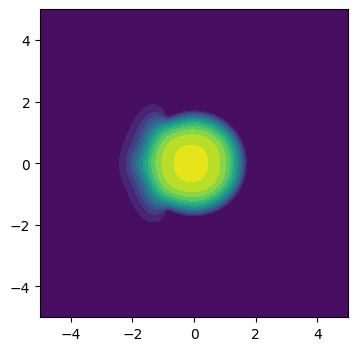

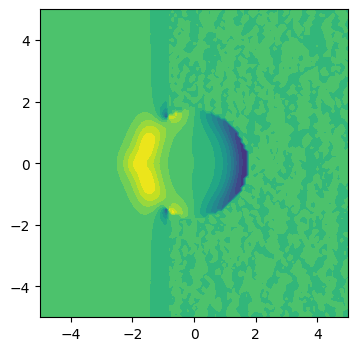

In [45]:

voltages = {
    'half_donut_top':0.115,
    'half_donut_bottom':0.115,
    'gate_top':0,
    'gate_bottom':0,
    'reservoir':0,
    'center':0.11,
    'guard':0,
}

clist = [GRAY, BLUE, YELLOW2, RED, GREEN, YELLOW]
fig = plt.figure(figsize=(12,4))
ax = fig.add_subplot(111)

phi.plot_potential_2D(phi.Phi, voltages, ax=ax, zero_line=False)#, cmap='RdGy')


plt.gca().set_aspect('equal')
plt.show()

fig = plt.figure(figsize=(12,4))
ax = fig.add_subplot(111)

ex.plot_potential_2D(ex.Ex, voltages, ax=ax, zero_line=False)#, cmap='RdGy')

plt.gca().set_aspect('equal')
plt.show()

In [46]:
total_phi_1 = 0.11*phi.Phi["center"] + 0.115*phi.Phi["center"]
total_phi_1 = total_phi_1.T
total_phi_2 = 0.11*phi.Phi["center"] + 0.15*phi.Phi["center"]
total_phi_2 = total_phi_2.T
x = 1e-6*phi.Phi["xlist"]
y = 1e-6*phi.Phi["ylist"]
field_x_1 = np.gradient(total_phi_1, x, axis=1)
field_y_1 = np.gradient(total_phi_1, y, axis=0)

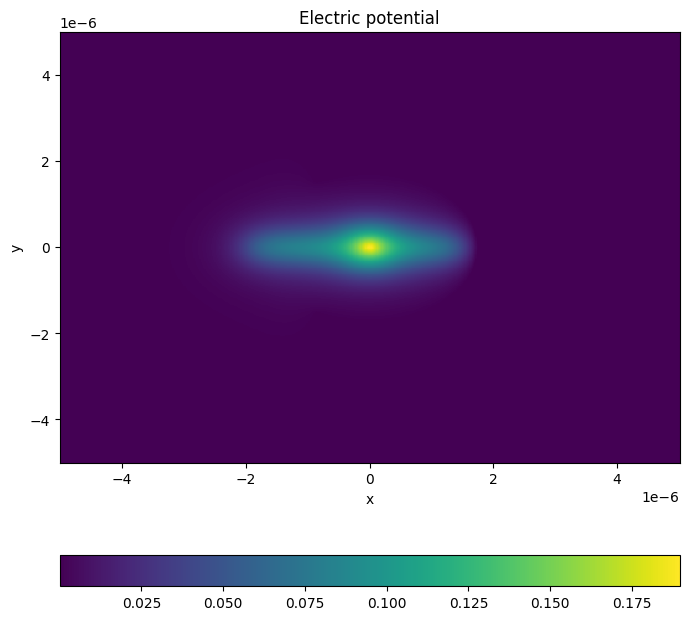

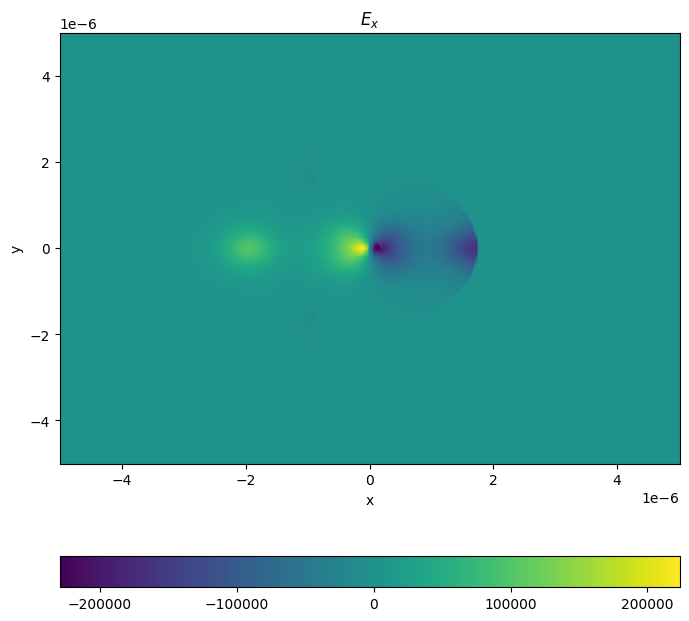

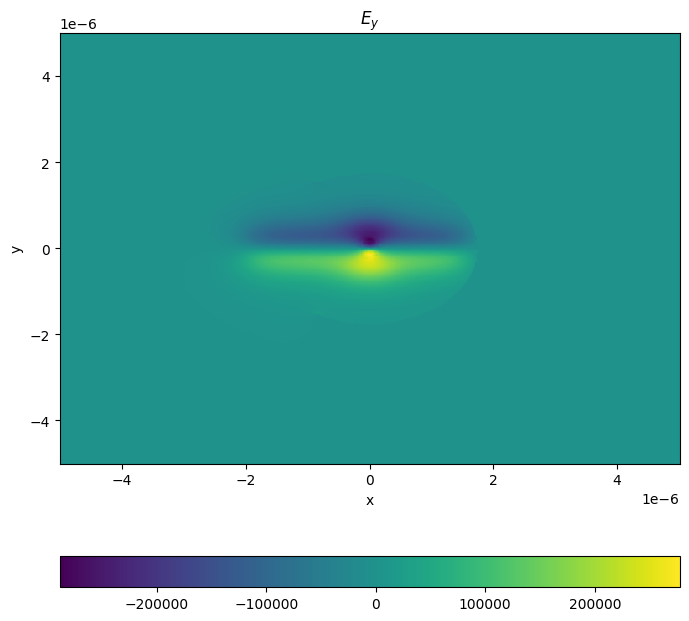

In [47]:
fig, axes = plt.subplots(1, 1, figsize=(8, 8))

cplot = axes.pcolormesh(x, y, total_phi_1)
fig.colorbar(cplot, ax=axes, orientation='horizontal')
plt.title("Electric potential")
plt.xlabel('x')
plt.ylabel('y')
plt.show()

fig, axes = plt.subplots(1, 1, figsize=(8, 8))

cplot = axes.pcolormesh(x, y, field_x_1)
fig.colorbar(cplot, ax=axes, orientation='horizontal')
plt.title("$E_x$")
plt.xlabel('x')
plt.ylabel('y')
plt.show()

fig, axes = plt.subplots(1, 1, figsize=(8, 8))

cplot = axes.pcolormesh(x, y, field_y_1)
fig.colorbar(cplot, ax=axes, orientation='horizontal')
plt.title("$E_y$")
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [48]:
# creates the csv files with the total potential
np.savetxt(dirname+'/Total_Potential_ver1.csv', total_phi_1, delimiter=',')
np.savetxt(dirname+'/Total_Potential_ver2.csv', total_phi_2, delimiter=',')

__Comparison to COMSOL ver 1:__

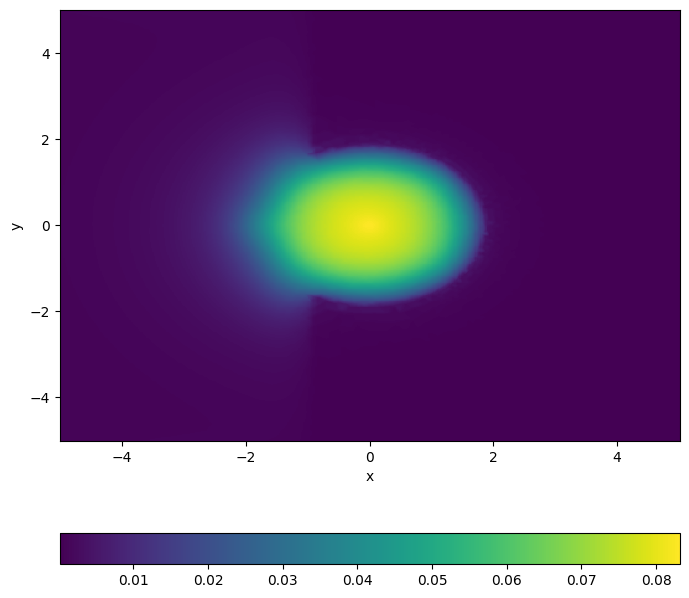